# Analyse descriptive: Classifications NLP

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Style global
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "teal"   : "#0D9488",
    "blue"   : "#2563EB",
    "purple" : "#7C3AED",
    "amber"  : "#D97706",
    "coral"  : "#EF4444",
    "green"  : "#059669",
    "gray"   : "#6B7280",
}

TOPIC_COLORS = {
    "opportunity"   : COLORS["amber"],
    "adoption"      : COLORS["teal"],
    "laborsaving"   : COLORS["coral"],
    "rd_investment" : COLORS["blue"],
    "none"          : COLORS["gray"],
}


In [7]:
# Charger les données
df = pd.read_csv("../data/processed/panel_with_topics.csv")
print(f"Panel chargé : {df.shape[0]} firm-years, {df['ticker'].nunique()} firmes, "
      f"{df['year'].nunique()} années ({df['year'].min()}-{df['year'].max()})")

Panel chargé : 974 firm-years, 146 firmes, 7 années (2018-2024)


In [8]:
# Chiffres clés du panel

print("=" * 55)
print("VUE D'ENSEMBLE DU PANEL")
print("=" * 55)
print(f"Firm-years totaux     : {len(df)}")
print(f"Firmes uniques        : {df['ticker'].nunique()}")
print(f"Années couvertes      : {df['year'].min()}-{df['year'].max()}")
print(f"Secteurs              : {df['sector'].nunique()}")
print()
print("Firmes par secteur :")
print(df.groupby("sector")["ticker"].nunique().sort_values(ascending=False).to_string())
print()
print("Observations par année :")
print(df["year"].value_counts().sort_index().to_string())

VUE D'ENSEMBLE DU PANEL
Firm-years totaux     : 974
Firmes uniques        : 146
Années couvertes      : 2018-2024
Secteurs              : 6

Firmes par secteur :
sector
Information Technology    55
Financials                28
Industrials               27
Health Care               20
Communication Services    12
Energy                     4

Observations par année :
year
2018    127
2019    134
2020    139
2021    142
2022    143
2023    144
2024    145


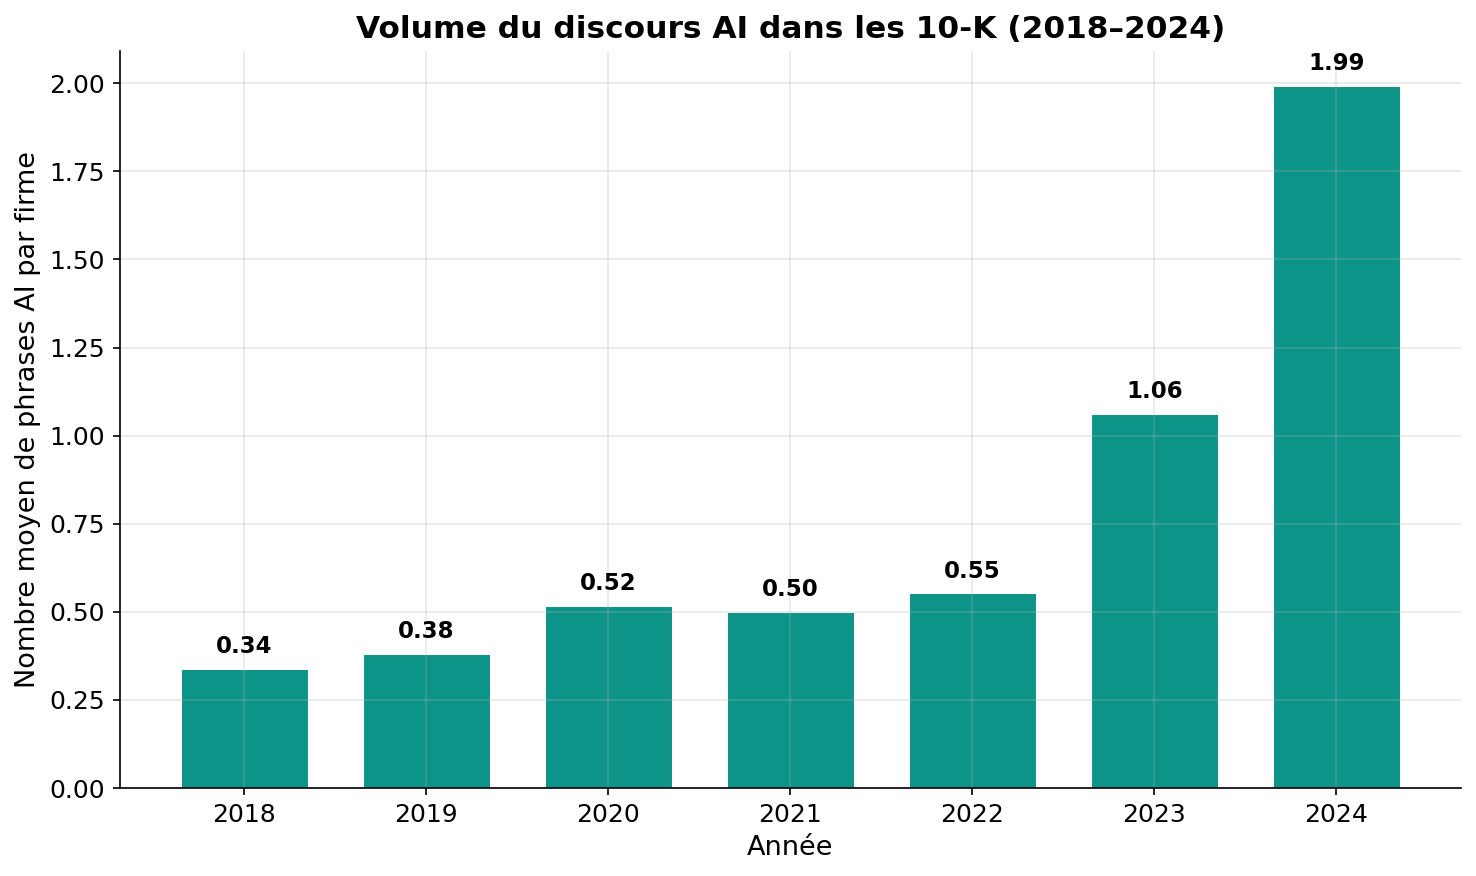

In [13]:
# Explosion du discours AI dans les 10-K

yearly_ai = df.groupby("year")["n_ai_sentences"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(yearly_ai.index, yearly_ai.values, color=COLORS["teal"],
              edgecolor="white", linewidth=0.5, width=0.7)

# Annoter les barres
for bar, val in zip(bars, yearly_ai.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("Année", fontsize=13)
ax.set_ylabel("Nombre moyen de phrases AI par firme", fontsize=13)
ax.set_title("Volume du discours AI dans les 10-K (2018–2024)", fontsize=15, fontweight="bold")
ax.set_xticks(yearly_ai.index)

plt.tight_layout()
plt.savefig("../data/outputs/fig_ai_sentences_per_year.png", bbox_inches="tight")
plt.show()

In [14]:
# Chiffre clé
ratio_2024_2018 = yearly_ai.iloc[-1] / yearly_ai.iloc[0]
print(f"\n× {ratio_2024_2018:.1f} entre {yearly_ai.index[0]} et {yearly_ai.index[-1]}")


× 5.9 entre 2018 et 2024


In [15]:
n_ai   = int(df["n_ai_sentences"].sum())
n_spec = int(df["n_speculative"].sum())
n_oper = int(df["n_operational"].sum())
n_fy_with_ai = (df["n_ai_sentences"] > 0).sum()
 
print("=" * 55)
print("NIVEAU 1 — CHIFFRES CLÉS")
print("=" * 55)
print(f"Phrases AI totales identifiées   : {n_ai}")
print(f"  dont speculative (futur)       : {n_spec} ({100*n_spec/n_ai:.0f}%)")
print(f"  dont operational (présent)     : {n_oper} ({100*n_oper/n_ai:.0f}%)")
print(f"Firm-years avec ≥1 phrase AI     : {n_fy_with_ai}/{len(df)} ({100*n_fy_with_ai/len(df):.0f}%)")
print(f"Ratio moyen (spec_vs_oper_ratio) : {df['spec_vs_oper_ratio'].mean():.4f}")

NIVEAU 1 — CHIFFRES CLÉS
Phrases AI totales identifiées   : 758
  dont speculative (futur)       : 173 (23%)
  dont operational (présent)     : 585 (77%)
Firm-years avec ≥1 phrase AI     : 301/974 (31%)
Ratio moyen (spec_vs_oper_ratio) : 0.4598


In [17]:
import re
from pathlib import Path
 
MDA_DIR = Path("../data/raw/mda_texts")
 
AI_PATTERN = re.compile(
    r"artificial intelligence|machine learning|deep learning|neural network|"
    r"large language model|generative ai|natural language processing|"
    r"computer vision|ai[- ]powered|ai[- ]driven|ai[- ]enabled|\bai\b",
    re.IGNORECASE
)
 
FUTURE_PATTERN = re.compile(
    r"\bwill\b|\bplan(?:s|ned)?\s+to\b|\bintend(?:s|ed)?\s+to\b|"
    r"\bexpect(?:s|ed)?\s+to\b|\baim(?:s|ed)?\s+to\b|\bgoing\s+to\b|"
    r"\bseek(?:s|ing)?\s+to\b|\bcommit(?:ted|s)?\s+to\b|"
    r"\bwould\b|\bcould\b|\bmay\b|\bmight\b|"
    r"\bfuture\b|\bupcoming\b|\bforecast\b|\bprojected?\b",
    re.IGNORECASE
)
 
def get_examples(tickers=None, max_per_type=12):
    """Lit les textes MD&A et extrait des exemples de phrases AI."""
    if tickers is None:
        # Prendre les firmes avec le plus de phrases AI
        top = df.groupby("ticker")["n_ai_sentences"].sum().nlargest(15).index.tolist()
        tickers = top
 
    speculative_examples = []
    operational_examples = []
 
    for ticker in tickers:
        for year in range(2018, 2025):
            txt_path = MDA_DIR / f"{ticker}_{year}.txt"
            if not txt_path.exists():
                continue
 
            text = txt_path.read_text(encoding="utf-8", errors="ignore")
            sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text)
                         if len(s.strip()) > 30]
 
            for sent in sentences:
                if not AI_PATTERN.search(sent):
                    continue
                # Tronquer les phrases trop longues
                display = sent[:200] + "..." if len(sent) > 200 else sent
 
                if FUTURE_PATTERN.search(sent):
                    if len(speculative_examples) < max_per_type:
                        speculative_examples.append({
                            "ticker": ticker, "year": year,
                            "type": "SPECULATIVE", "sentence": display
                        })
                else:
                    if len(operational_examples) < max_per_type:
                        operational_examples.append({
                            "ticker": ticker, "year": year,
                            "type": "OPERATIONAL", "sentence": display
                        })
 
            if (len(speculative_examples) >= max_per_type and
                len(operational_examples) >= max_per_type):
                break
        if (len(speculative_examples) >= max_per_type and
            len(operational_examples) >= max_per_type):
            break
 
    return speculative_examples, operational_examples
 
 
spec_ex, oper_ex = get_examples()
 
print("=" * 70)
print("EXEMPLES DE PHRASES SPECULATIVE (forward-looking)")
print("=" * 70)
for i, ex in enumerate(spec_ex, 1):
    print(f"\n[{i}] {ex['ticker']} ({ex['year']})")
    print(f"    {ex['sentence']}")
 
print("\n")
print("=" * 70)
print("EXEMPLES DE PHRASES OPERATIONAL (past/present)")
print("=" * 70)
for i, ex in enumerate(oper_ex, 1):
    print(f"\n[{i}] {ex['ticker']} ({ex['year']})")
    print(f"    {ex['sentence']}")
 
print(f"\n\nTotal exemples : {len(spec_ex)} speculative, {len(oper_ex)} operational")

EXEMPLES DE PHRASES SPECULATIVE (forward-looking)

[1] NVDA (2020)
    in our data center platform, we announced the nvidia a100 tensor core gpu and dgx a100, the first products based on the nvidia ampere architecture; announced more than 50 nvidia a100-powered systems w...

[2] NVDA (2020)
    in our automotive platform, we announced with mercedes-benz that the automaker will launch software-defined, intelligent vehicles using end-to-end nvidia technology starting in 2024; announced that nv...

[3] NVDA (2021)
    in our data center platform, we launched new nvidia a30 and a10 gpus for mainstream ai, data analytics and graphics; debuted a new class of nvidia-certified systems with leading server oems; unveiled ...

[4] NVDA (2021)
    32 in our automotive platform, we unveiled the nvidia drive atlan next-generation soc; announced design wins with mercedes-benz for the ai cockpit in its new eqs sedan; with volvo cars for the autonom...

[5] NVDA (2021)
    in fiscal year 2023, we plan 

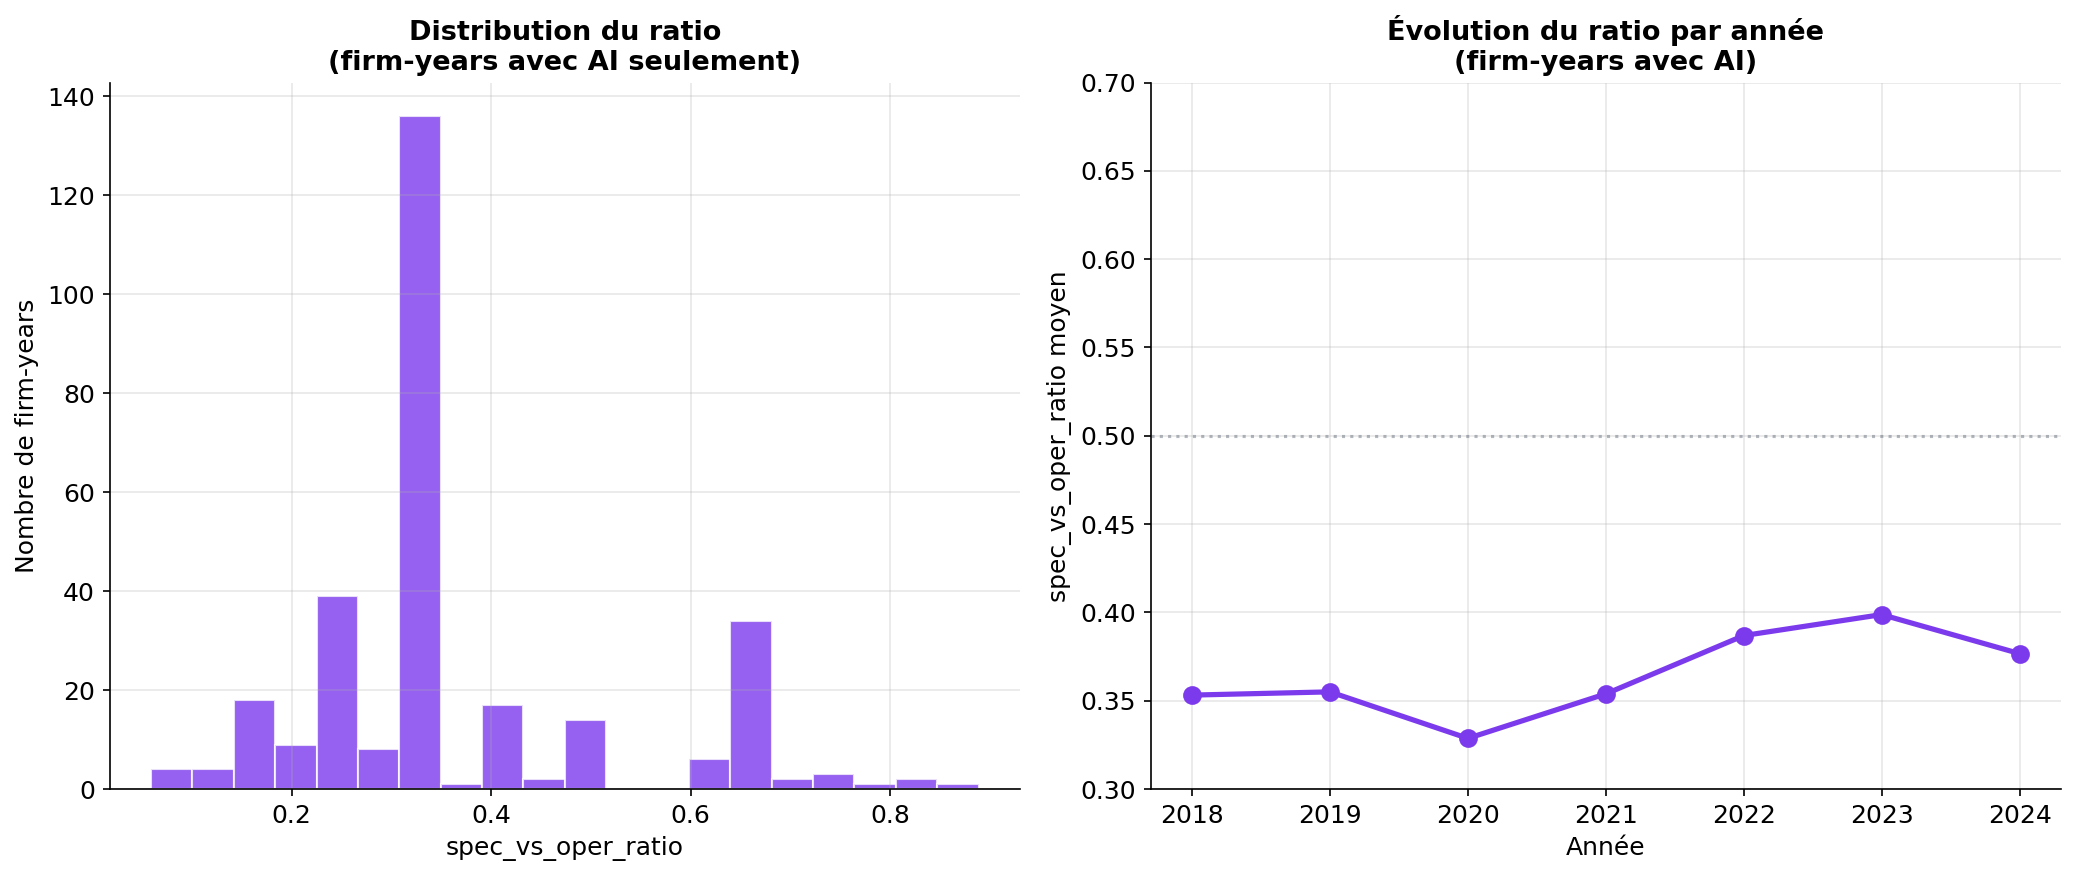

Firm-years avec AI : 301 / 974 (31%)
  > 0.5 (spéculatif)   : 49
  < 0.5 (opérationnel) : 238
  = 0.5 (neutre)       : 14


In [21]:
# Le ratio speculation / opérationnel

# Exclure les firm-years sans AI (ratio = 0.5 par défaut)
df_with_ai = df[df["n_ai_sentences"] > 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gauche : distribution du ratio (avec AI seulement)
ax1.hist(df_with_ai["spec_vs_oper_ratio"], bins=20, color=COLORS["purple"],
         edgecolor="white", alpha=0.8)
ax1.set_xlabel("spec_vs_oper_ratio", fontsize=12)
ax1.set_ylabel("Nombre de firm-years", fontsize=12)
ax1.set_title("Distribution du ratio\n(firm-years avec AI seulement)", fontsize=13, fontweight="bold")

# Droite : évolution par année (avec AI seulement)
yearly_ratio = df_with_ai.groupby("year")["spec_vs_oper_ratio"].mean()
ax2.plot(yearly_ratio.index, yearly_ratio.values,
         marker="o", linewidth=2.5, color=COLORS["purple"], markersize=8)

ax2.axhline(y=0.5, color=COLORS["gray"], linestyle=":", alpha=0.5)
ax2.set_xlabel("Année", fontsize=12)
ax2.set_ylabel("spec_vs_oper_ratio moyen", fontsize=12)
ax2.set_title("Évolution du ratio par année\n(firm-years avec AI)", fontsize=13, fontweight="bold")
ax2.set_xticks(yearly_ratio.index)
ax2.set_ylim(0.3, 0.7)

plt.tight_layout()
plt.savefig("../data/outputs/fig_spec_ratio.png", bbox_inches="tight")
plt.show()

# Stats clés
print(f"Firm-years avec AI : {len(df_with_ai)} / {len(df)} ({100*len(df_with_ai)/len(df):.0f}%)")
print(f"  > 0.5 (spéculatif)   : {(df_with_ai['spec_vs_oper_ratio'] > 0.5).sum()}")
print(f"  < 0.5 (opérationnel) : {(df_with_ai['spec_vs_oper_ratio'] < 0.5).sum()}")
print(f"  = 0.5 (neutre)       : {(df_with_ai['spec_vs_oper_ratio'] == 0.5).sum()}")


In [22]:
# Tableau récapitulatif Niveau 1

n_spec = int(df["n_speculative"].sum())
n_oper = int(df["n_operational"].sum())
n_ai   = int(df["n_ai_sentences"].sum())

summary_n1 = pd.DataFrame({
    "Métrique": [
        "Phrases AI totales identifiées",
        "  dont speculative (forward-looking)",
        "  dont operational (past/present)",
        "Firm-years avec ≥1 phrase AI",
        "Firm-years ratio > 0.5 (spéculatif)",
        "Firm-years ratio < 0.5 (opérationnel)",
        "Firm-years ratio = 0.5 (aucune phrase AI)",
    ],
    "Valeur": [
        f"{n_ai}",
        f"{n_spec} ({100*n_spec/n_ai:.0f}%)",
        f"{n_oper} ({100*n_oper/n_ai:.0f}%)",
        f"{(df['n_ai_sentences']>0).sum()} / {len(df)} ({100*(df['n_ai_sentences']>0).sum()/len(df):.0f}%)",
        f"{(df['spec_vs_oper_ratio']>0.5).sum()}",
        f"{(df['spec_vs_oper_ratio']<0.5).sum()}",
        f"{(df['spec_vs_oper_ratio']==0.5).sum()}",
    ]
})
print(summary_n1.to_string(index=False))


                                 Métrique          Valeur
           Phrases AI totales identifiées             758
       dont speculative (forward-looking)       173 (23%)
          dont operational (past/present)       585 (77%)
             Firm-years avec ≥1 phrase AI 301 / 974 (31%)
      Firm-years ratio > 0.5 (spéculatif)              49
    Firm-years ratio < 0.5 (opérationnel)             238
Firm-years ratio = 0.5 (aucune phrase AI)             687


In [23]:
# Specificity

n_total = len(df)
n_with_spec = (df["n_speculative"] > 0).sum()
n_with_specificity = (df["specificity_score"] > 0).sum()

print("=" * 55)
print("NIVEAU 2 — SPECIFICITY SCORING")
print("=" * 55)
print(f"Firm-years avec phrases spéculatives : {n_with_spec}")
print(f"Firm-years avec specificity > 0      : {n_with_specificity}")
print(f"Pourcentage vague (= 0)              : {100*(1 - n_with_specificity/n_total):.1f}%")
print()

# Les seuls cas
pos = df[df["specificity_score"] > 0][["ticker", "year", "n_speculative", "specificity_score"]]
pos = pos.sort_values("specificity_score", ascending=False)
print("Les seules firmes avec des promesses AI chiffrées :")
print(pos.to_string(index=False))


NIVEAU 2 — SPECIFICITY SCORING
Firm-years avec phrases spéculatives : 105
Firm-years avec specificity > 0      : 4
Pourcentage vague (= 0)              : 99.6%

Les seules firmes avec des promesses AI chiffrées :
ticker  year  n_speculative  specificity_score
  META  2024              3           0.766200
   BKR  2022              1           0.369720
  ADSK  2023              1           0.074856
   AXP  2020              1           0.042544


KeyError: 'name'

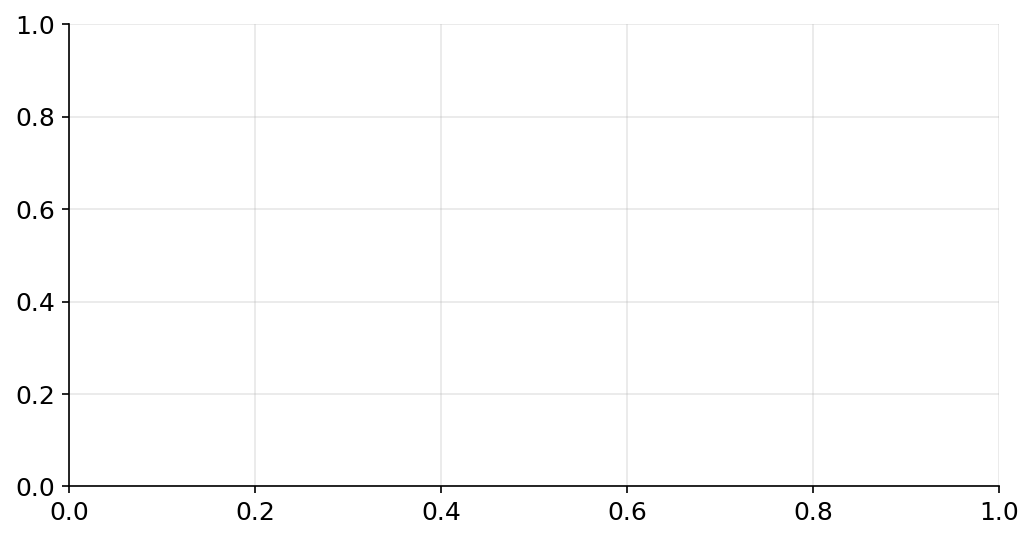

In [ ]:
# Graphique
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{r['ticker']} ({int(r['year'])})" for _, r in pos.iterrows()]
values = pos["specificity_score"].values
bars = ax.barh(labels, values, color=COLORS["amber"], edgecolor="white")
ax.set_xlabel("Specificity Score", fontsize=12)
ax.set_title("Firm-years avec promesses AI chiffrées",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()

# Annoter
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=11)

plt.tight_layout()
plt.savefig("../data/outputs/fig_specificity.png", bbox_inches="tight")
plt.show()

In [ ]:


# %% CELL 6 — Niveau 3 : Topic classification — stacked bar chart par année
# ═══════════════════════════════════════════════════════════════
# SLIDE 5 : Évolution des 4 topics par année
# ═══════════════════════════════════════════════════════════════

ct = pd.crosstab(df["year"], df["topic_dominant"])
# Réordonner les colonnes
topic_order = ["opportunity", "adoption", "rd_investment", "laborsaving", "none"]
ct = ct[[c for c in topic_order if c in ct.columns]]

fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bar sans "none" pour voir les proportions actives
ct_active = ct.drop(columns=["none"], errors="ignore")
ct_active.plot(
    kind="bar", stacked=True, ax=ax,
    color=[TOPIC_COLORS[c] for c in ct_active.columns],
    edgecolor="white", linewidth=0.5, width=0.75
)

ax.set_xlabel("Année", fontsize=13)
ax.set_ylabel("Nombre de firm-years", fontsize=13)
ax.set_title("Évolution du topic dominant par année (hors 'none')", fontsize=15, fontweight="bold")
ax.legend(title="Topic", fontsize=10, title_fontsize=11, loc="upper left")
ax.set_xticklabels(ct.index, rotation=0)

# Ligne ChatGPT
ax.axvline(x=4.5, color=COLORS["coral"], linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(4.6, ax.get_ylim()[1] * 0.9, "ChatGPT", fontsize=10, color=COLORS["coral"])

plt.tight_layout()
plt.savefig("data/outputs/fig_topics_stacked.png", bbox_inches="tight")
plt.show()

# Tableau
print("\nFirm-years par topic dominant par année :")
print(ct.to_string())


# %% CELL 7 — Niveau 3 : Densité moyenne par topic par année (line chart)
# ═══════════════════════════════════════════════════════════════
# SLIDE 5-6 : Évolution continue des scores topics
# ═══════════════════════════════════════════════════════════════

topic_cols = ["topic_opportunity", "topic_adoption", "topic_laborsaving", "topic_rd_investment"]
yearly_topics = df.groupby("year")[topic_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))

for col in topic_cols:
    short = col.replace("topic_", "")
    ax.plot(yearly_topics.index, yearly_topics[col],
            marker="o", linewidth=2.5, markersize=8,
            color=TOPIC_COLORS[short], label=short)

ax.axvline(x=2022.5, color=COLORS["coral"], linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(2022.6, ax.get_ylim()[1] * 0.92, "ChatGPT", fontsize=10, color=COLORS["coral"])

ax.set_xlabel("Année", fontsize=13)
ax.set_ylabel("Score moyen (par 1000 mots)", fontsize=13)
ax.set_title("Densité des 4 topics AI par année", fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.set_xticks(yearly_topics.index)

plt.tight_layout()
plt.savefig("data/outputs/fig_topics_lines.png", bbox_inches="tight")
plt.show()


# %% CELL 8 — Niveau 3 : Avant vs Après ChatGPT (bar comparatif)
# ═══════════════════════════════════════════════════════════════
# SLIDE 6 : Explosion post-ChatGPT par topic
# ═══════════════════════════════════════════════════════════════

pre  = df[df["year"] <= 2022][topic_cols].mean()
post = df[df["year"] >= 2023][topic_cols].mean()
multiplier = post / pre

comp = pd.DataFrame({"Pre-ChatGPT": pre, "Post-ChatGPT": post, "Multiplication": multiplier})
comp.index = [c.replace("topic_", "") for c in comp.index]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comp))
w = 0.35

bars1 = ax.bar(x - w/2, comp["Pre-ChatGPT"],  w, label="Pre-ChatGPT (2018–2022)",
               color=COLORS["gray"], edgecolor="white")
bars2 = ax.bar(x + w/2, comp["Post-ChatGPT"], w, label="Post-ChatGPT (2023–2024)",
               color=COLORS["teal"], edgecolor="white")

# Annoter les multiplications
for i, (_, row) in enumerate(comp.iterrows()):
    ax.text(i + w/2, row["Post-ChatGPT"] + 0.002,
            f"×{row['Multiplication']:.1f}",
            ha="center", fontsize=12, fontweight="bold", color=COLORS["coral"])

ax.set_ylabel("Score moyen (par 1000 mots)", fontsize=13)
ax.set_title("Discours AI avant vs après ChatGPT", fontsize=15, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(comp.index, fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("data/outputs/fig_pre_post_chatgpt.png", bbox_inches="tight")
plt.show()

# Tableau
print("\nComparaison pre vs post ChatGPT :")
print(comp.round(4).to_string())


# %% CELL 9 — Heatmap secteur × topic
# ═══════════════════════════════════════════════════════════════
# SLIDE 5 ALTERNATIVE : Quels secteurs parlent de quoi
# ═══════════════════════════════════════════════════════════════

sector_topics = df.groupby("sector")[topic_cols].mean()
sector_topics.columns = [c.replace("topic_", "") for c in sector_topics.columns]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(sector_topics.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(sector_topics.columns)))
ax.set_xticklabels(sector_topics.columns, fontsize=12)
ax.set_yticks(range(len(sector_topics.index)))
ax.set_yticklabels(sector_topics.index, fontsize=11)
ax.set_title("Intensité du discours AI par secteur et topic", fontsize=14, fontweight="bold")

# Annoter les cellules
for i in range(len(sector_topics.index)):
    for j in range(len(sector_topics.columns)):
        val = sector_topics.iloc[i, j]
        color = "white" if val > sector_topics.values.max() * 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=10, color=color)

plt.colorbar(im, ax=ax, label="Score moyen /1000 mots")
plt.tight_layout()
plt.savefig("data/outputs/fig_heatmap_sector_topic.png", bbox_inches="tight")
plt.show()


# %% CELL 10 — Top 10 firmes par phrases AI
# ═══════════════════════════════════════════════════════════════
# SLIDE 7 : Firmes les plus intenses en discours AI
# ═══════════════════════════════════════════════════════════════

# Exclure doublons GOOG
df_dedup = df[~df["ticker"].isin(["GOOG", "NWS"])].copy()

top10 = (df_dedup.groupby("ticker")["n_ai_sentences"]
         .sum()
         .nlargest(10)
         .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index, top10.values, color=COLORS["blue"], edgecolor="white")

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{int(val)}", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Total phrases AI (2018–2024)", fontsize=13)
ax.set_title("Top 10 firmes — Volume de discours AI", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("data/outputs/fig_top10_firms.png", bbox_inches="tight")
plt.show()


# %% CELL 11 — Trajectoire individuelle NVDA / MSFT / IBM
# ═══════════════════════════════════════════════════════════════
# SLIDE 7 : Trajectoires individuelles
# ═══════════════════════════════════════════════════════════════

showcase = ["NVDA", "MSFT", "IBM"]
showcase_colors = [COLORS["teal"], COLORS["blue"], COLORS["amber"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gauche : n_ai_sentences
ax = axes[0]
for ticker, color in zip(showcase, showcase_colors):
    firm = df[df["ticker"] == ticker].sort_values("year")
    ax.plot(firm["year"], firm["n_ai_sentences"],
            marker="o", linewidth=2.5, color=color, label=ticker, markersize=7)
ax.axvline(x=2022.5, color=COLORS["coral"], linestyle="--", alpha=0.5)
ax.set_title("Phrases AI par année", fontsize=13, fontweight="bold")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de phrases AI")
ax.legend(fontsize=11)

# Droite : spec_vs_oper_ratio
ax = axes[1]
for ticker, color in zip(showcase, showcase_colors):
    firm = df[df["ticker"] == ticker].sort_values("year")
    ax.plot(firm["year"], firm["spec_vs_oper_ratio"],
            marker="o", linewidth=2.5, color=color, label=ticker, markersize=7)
ax.axhline(y=0.5, color=COLORS["gray"], linestyle=":", alpha=0.5)
ax.axvline(x=2022.5, color=COLORS["coral"], linestyle="--", alpha=0.5)
ax.set_title("Ratio speculation/opérationnel", fontsize=13, fontweight="bold")
ax.set_xlabel("Année")
ax.set_ylabel("spec_vs_oper_ratio")
ax.set_ylim(0.2, 0.9)
ax.legend(fontsize=11)

plt.suptitle("NVIDIA vs Microsoft vs IBM — Trajectoires AI", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/outputs/fig_trajectories.png", bbox_inches="tight")
plt.show()


# %% CELL 12 — Scatter : spec_ratio vs pe_premium
# ═══════════════════════════════════════════════════════════════
# SLIDE 8 : Lien narratif AI → valorisation (transition vers régression)
# ═══════════════════════════════════════════════════════════════

# Uniquement firm-years avec AI et pe_premium valide
df_scatter = df_dedup[
    (df_dedup["n_ai_sentences"] > 0) &
    (df_dedup["pe_premium"].notna()) &
    (df_dedup["pe_premium"] < 200)    # exclure outliers extrêmes pour lisibilité
].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gauche : spec_ratio vs pe_premium
ax1.scatter(df_scatter["spec_vs_oper_ratio"], df_scatter["pe_premium"],
            alpha=0.5, s=40, color=COLORS["purple"], edgecolor="white", linewidth=0.3)
z = np.polyfit(df_scatter["spec_vs_oper_ratio"].dropna(),
               df_scatter.loc[df_scatter["spec_vs_oper_ratio"].notna(), "pe_premium"].dropna(),
               1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter["spec_vs_oper_ratio"].min(),
                     df_scatter["spec_vs_oper_ratio"].max(), 100)
ax1.plot(x_line, p(x_line), color=COLORS["coral"], linewidth=2, linestyle="--")
ax1.set_xlabel("spec_vs_oper_ratio", fontsize=12)
ax1.set_ylabel("P/E Premium", fontsize=12)
ax1.set_title("Ratio spéculatif vs P/E Premium", fontsize=13, fontweight="bold")

# Droite : n_ai_sentences vs pe_premium
ax2.scatter(df_scatter["n_ai_sentences"], df_scatter["pe_premium"],
            alpha=0.5, s=40, color=COLORS["teal"], edgecolor="white", linewidth=0.3)
ax2.set_xlabel("Nombre de phrases AI", fontsize=12)
ax2.set_ylabel("P/E Premium", fontsize=12)
ax2.set_title("Volume AI vs P/E Premium", fontsize=13, fontweight="bold")

plt.suptitle("Lien entre narratif AI et valorisation boursière",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/outputs/fig_scatter_ai_pe.png", bbox_inches="tight")
plt.show()

print(f"Observations dans le scatter : {len(df_scatter)}")
corr = df_scatter[["spec_vs_oper_ratio", "n_ai_sentences", "pe_premium"]].corr()
print(f"\nCorrélations avec pe_premium :")
print(f"  spec_vs_oper_ratio : {corr.loc['spec_vs_oper_ratio', 'pe_premium']:.3f}")
print(f"  n_ai_sentences     : {corr.loc['n_ai_sentences', 'pe_premium']:.3f}")


# %% CELL 13 — Résumé chiffres clés pour la présentation
# ═══════════════════════════════════════════════════════════════
# SLIDE 8 : Résumé → transition vers régression
# ═══════════════════════════════════════════════════════════════

pre  = df[df["year"] <= 2022]
post = df[df["year"] >= 2023]

print("=" * 55)
print("3 FINDINGS CLÉS DES CLASSIFICATIONS")
print("=" * 55)
print()

ratio_vol = post["n_ai_sentences"].mean() / pre["n_ai_sentences"].mean()
print(f"1. VOLUME ×{ratio_vol:.1f}")
print(f"   Le discours AI a été multiplié par {ratio_vol:.1f} après ChatGPT")
print(f"   ({pre['n_ai_sentences'].mean():.2f} → {post['n_ai_sentences'].mean():.2f} phrases/firme)")
print()

n_vague = (df["specificity_score"] == 0).sum()
print(f"2. VAGUE À {100*n_vague/len(df):.1f}%")
print(f"   {n_vague}/{len(df)} firm-years : aucun chiffre concret dans les promesses")
print()

adoption_mult = post["topic_adoption"].mean() / pre["topic_adoption"].mean()
print(f"3. ADOPTION ×{adoption_mult:.1f}")
print(f"   La plus forte croissance post-ChatGPT parmi les 4 topics")
print(f"   ({pre['topic_adoption'].mean():.4f} → {post['topic_adoption'].mean():.4f})")
print()
print("→ Question : ce narratif gonfle-t-il les valorisations ?")
print("  → Régression panel à suivre")